# Linear Regression Example (Setup Test)

This notebook is a simple test to confirm that your Docker environment is working correctly.

It demonstrates:
- basic TensorFlow operations
- gradient-based optimization
- plotting with matplotlib

If this notebook runs without errors, your basic setup is ready for the workshop.

## Imports

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## Define Data and Model

In [2]:
x_train = tf.constant([1.0, 2.0, 3.0, 4.0])
y_train = tf.constant([42.0, 84.0, 126.0, 168.0])

weight = tf.Variable(10.0, dtype=tf.float32)

def linear_regression_model(x):
    return weight * x

def mse(y_obs, y_est):
    return tf.reduce_mean((y_obs - y_est)**2)

## Training the Model

In [3]:
epochs = 100
learning_rate = 1e-2

loss_history = []
weight_history = []

for epoch in range(1, epochs + 1):
    with tf.GradientTape() as tape:
        y_est = linear_regression_model(x_train)
        loss = mse(y_train, y_est)

    gradient = tape.gradient(loss, weight)
    weight.assign_sub(learning_rate * gradient)

    loss_history.append(loss.numpy())
    weight_history.append(weight.numpy())

    if epoch % 10 == 0:
        print(f'epoch {epoch:3d}: loss: {loss.numpy():.12e}, weight: {weight.numpy()}')

print(f'final:     loss: {loss.numpy():.12e}, weight: {weight.numpy()}')


epoch  10: loss: 4.120045166016e+02, weight: 35.70001983642578
epoch  20: loss: 1.596910762787e+01, weight: 40.75969314575195
epoch  30: loss: 6.189434528351e-01, weight: 41.75581741333008
epoch  40: loss: 2.399286627769e-02, weight: 41.95192337036133
epoch  50: loss: 9.298648801632e-04, weight: 41.990535736083984
epoch  60: loss: 3.607165490394e-05, weight: 41.99813461303711
epoch  70: loss: 1.396070729243e-06, weight: 41.9996337890625
epoch  80: loss: 5.282345227897e-08, weight: 41.99992752075195
epoch  90: loss: 1.746229827404e-09, weight: 41.9999885559082
epoch 100: loss: 9.204086381942e-10, weight: 41.9999885559082
final:     loss: 9.204086381942e-10, weight: 41.9999885559082


## Results

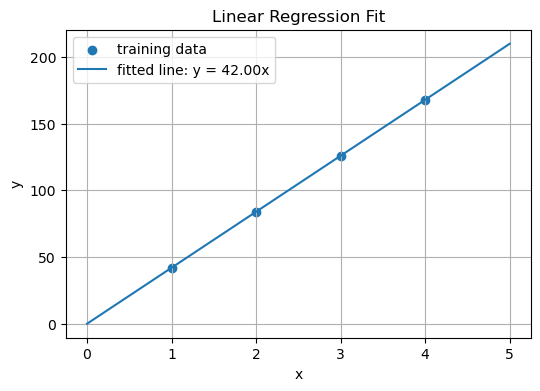

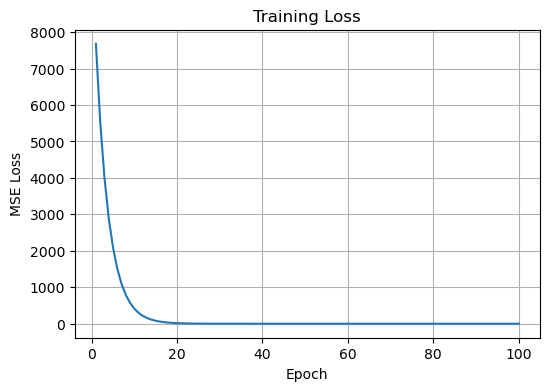

In [4]:
# ---- Plot 1: training data and fitted line ----
x_plot = np.linspace(0, 5, 100)
y_plot = weight.numpy() * x_plot

plt.figure(figsize=(6, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), label="training data")
plt.plot(x_plot, y_plot, label=f"fitted line: y = {weight.numpy():.2f}x")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot 2: loss curve ----
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()